# FIGS — Case Analysis & Display

Run (or load) a forecast for a HRRR cycle, render SPC-style probability /
categorical / median-intensity maps, and overlay the observed storm reports.

In [1]:
# Run with the `met` conda env kernel.
import warnings; warnings.filterwarnings('ignore')
import sys, numpy as np, pandas as pd, matplotlib.pyplot as plt
sys.path.insert(0, '..')   # so `import figs` works from notebooks/
from figs import config as C

In [2]:
from datetime import datetime, timezone, timedelta
from figs.model.predict import predict_forecast
from figs.products import plots, summary, cig, netcdf
from figs.data import reports, grid

# RUN   = datetime(2023, 4, 19, 18, tzinfo=timezone.utc)  # HRRR cycle to forecast
# RUN   = datetime(2024, 5, 6, 18, tzinfo=timezone.utc)  # HRRR cycle to forecast
# RUN   = datetime(2021, 12, 10, 21, tzinfo=timezone.utc)  # HRRR cycle to forecast
# RUN   = datetime(2022, 11, 29, 18, tzinfo=timezone.utc)  # HRRR cycle to forecast
# RUN   = datetime(2026, 6, 18, 18, tzinfo=timezone.utc)  # HRRR cycle to forecast
# RUN   = datetime(2024, 10, 9, 12, tzinfo=timezone.utc)  # HRRR cycle to forecast
RUN   = datetime(2024, 7, 8, 15, tzinfo=timezone.utc)  # HRRR cycle to forecast
FXX   = list(range(1, 13))                              # forecast hours
HAZARD = 'tor'                                          # 'tor' | 'wind' | 'hail'
MODELS = None                                           # None -> Data/models
DL_WORKERS = 8                                          # forecast hours downloaded concurrently

## Predict (or load a prepared netCDF)

In [3]:
from figs.model.predict import predict_or_load
try:
    # loads the run's netCDF if it exists (no re-download), else forecasts + writes it;
    # transient HRRR S3 errors (e.g. 503) are retried. Pass cache=False to force recompute.
    preds = predict_or_load(RUN, FXX, models_dir=MODELS, max_members=6, workers=DL_WORKERS)
    print(f'{len(preds)} forecast hours | netCDF: {netcdf.predictions_path(RUN)}')
except Exception as e:
    print('predict failed (need trained models?):', e)
    preds = None

loaded cached predictions: /Users/jwt/Documents/Code/FIGS/Data/products/figs_20240708_15Z.nc
12 forecast hours | netCDF: /Users/jwt/Documents/Code/FIGS/Data/products/figs_20240708_15Z.nc


## Map extent

Plan-view extent `[lon_min, lon_max, lat_min, lat_max]` for ALL plots below — kept
in its own cell AFTER predict so you can re-tune the zoom and re-run just the plots
without re-forecasting. `None` lets cartopy auto-fit the FIGS grid.

In [4]:
# MAP_EXTENT = [-110, -80, 25, 55]
# MAP_EXTENT = [-95, -80, 30, 45] # Ohio river valley
# MAP_EXTENT = [-95, -80, 25, 40] # Dixie
MAP_EXTENT = [-100, -80, 20, 40] # Dixie
# MAP_EXTENT = [-105, -90, 30, 45] # Plains
# MAP_EXTENT = [-85, -78, 23, 30] # Milton
plots.set_extent(MAP_EXTENT)

## Per-forecast-hour SPC-style probability map

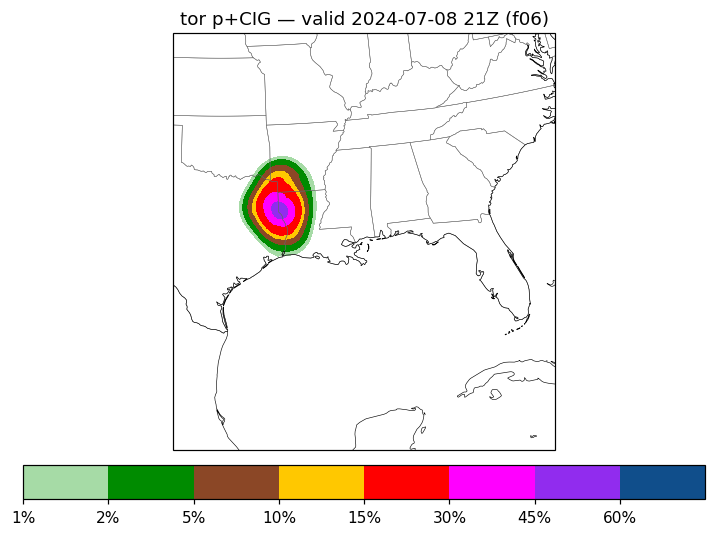

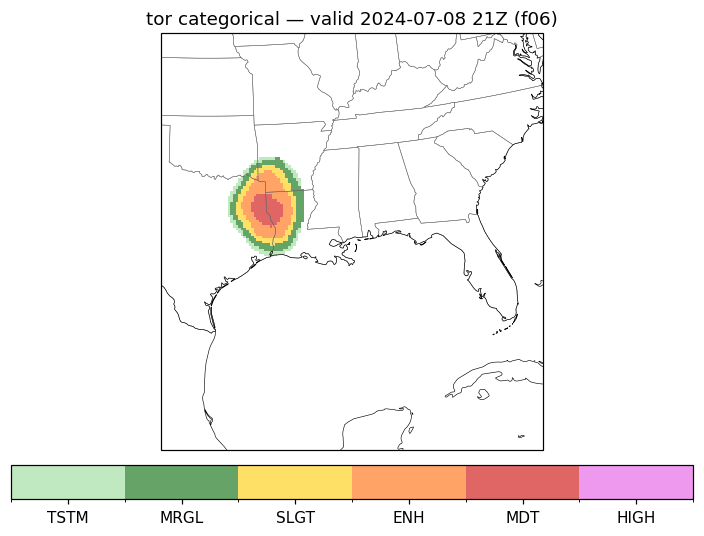

In [5]:
FH = 6  # forecast hour to display
if preds:
    p = preds[FH][f'p_{HAZARD}']
    dist = np.nan_to_num(preds[FH][f'dist_{HAZARD}'])
    risk = cig.categorical_risk(HAZARD, p*100, dist)
    vt = RUN + timedelta(hours=FH)
    plots.plot_probability(p, HAZARD, f'{HAZARD} p+CIG — valid {vt:%Y-%m-%d %HZ} (f{FH:02d})', '/tmp/_p.png')
    plots.plot_categorical(risk['category'], HAZARD, f'{HAZARD} categorical — valid {vt:%Y-%m-%d %HZ} (f{FH:02d})', '/tmp/_c.png')
    from IPython.display import Image, display
    display(Image('/tmp/_p.png')); display(Image('/tmp/_c.png'))

## Day-total (cumulative) risk + median / 75th / 90th-pct intensity

The cumulative daily **categorical** outlook is ALWAYS across all 3 hazards (the SPC Day-1 categorical = max category over tor/wind/hail). **Day-max** conditional-intensity is shown for **each** hazard at the **median**, the **75th percentile**, and the **90th percentile** (per-hour percentile bin, maxed over hours), masked to that hazard's threat area (day-max prob ≥ its lowest SPC level).

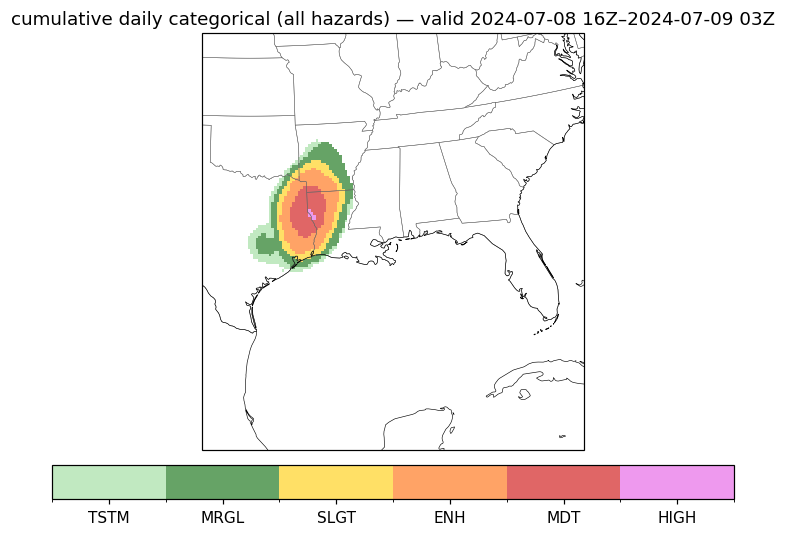

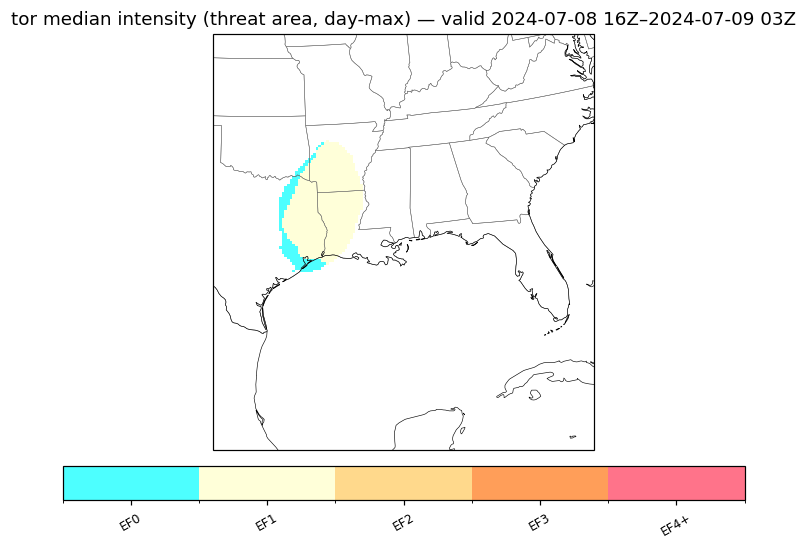

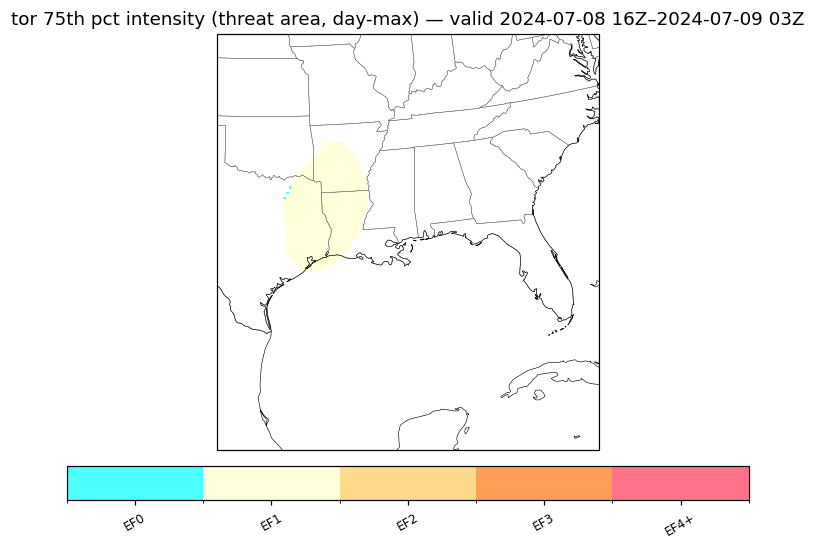

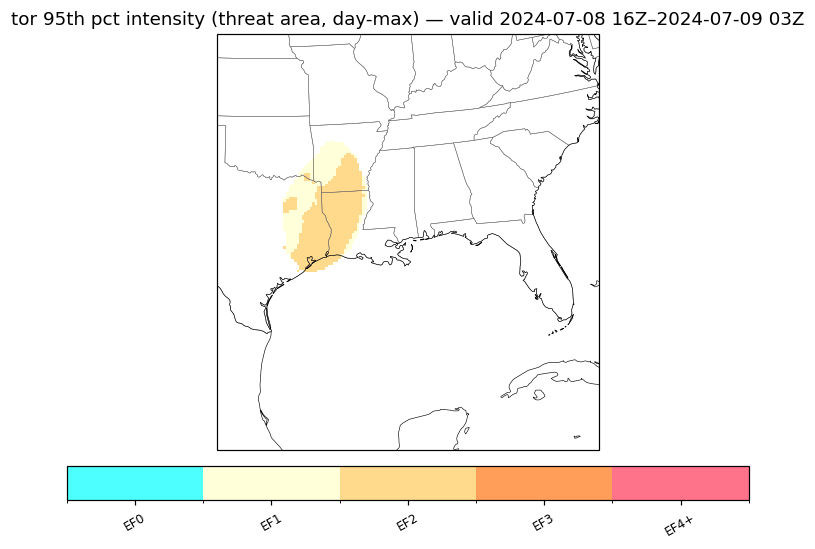

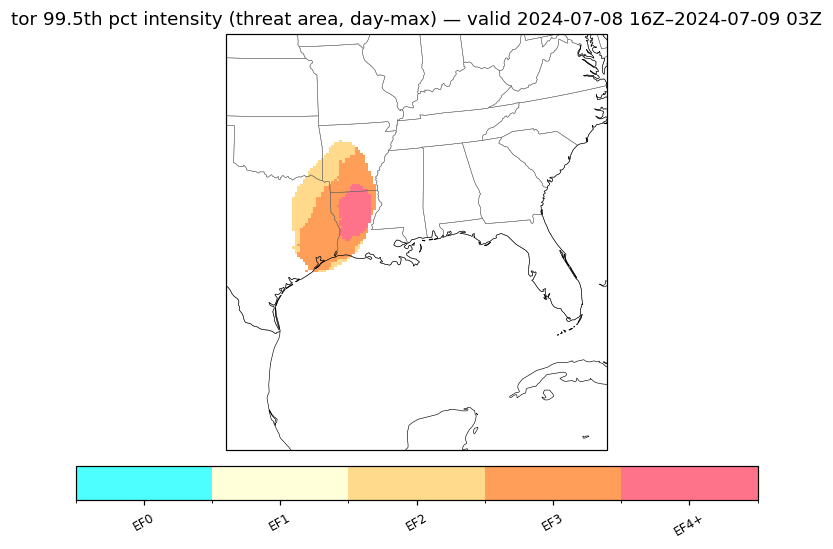

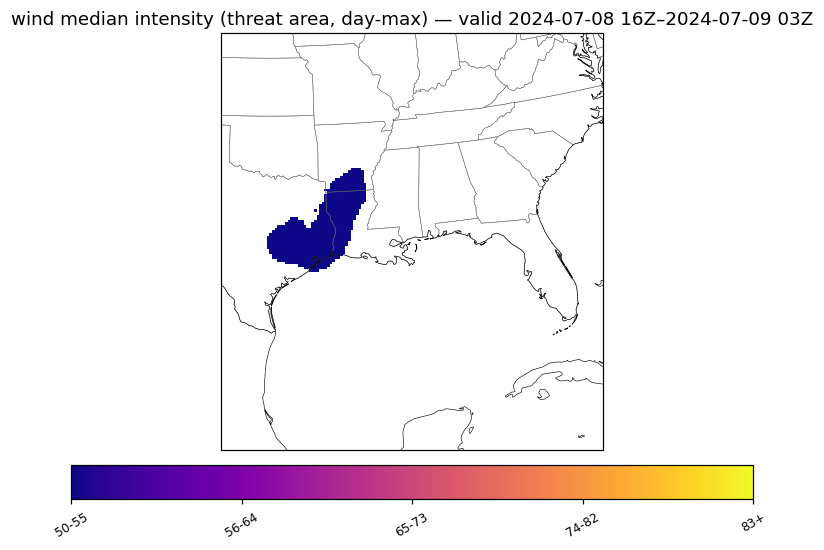

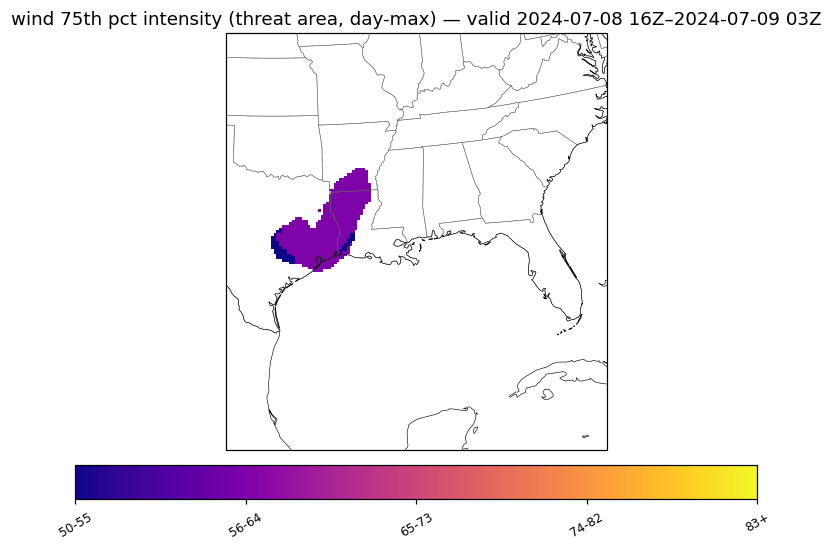

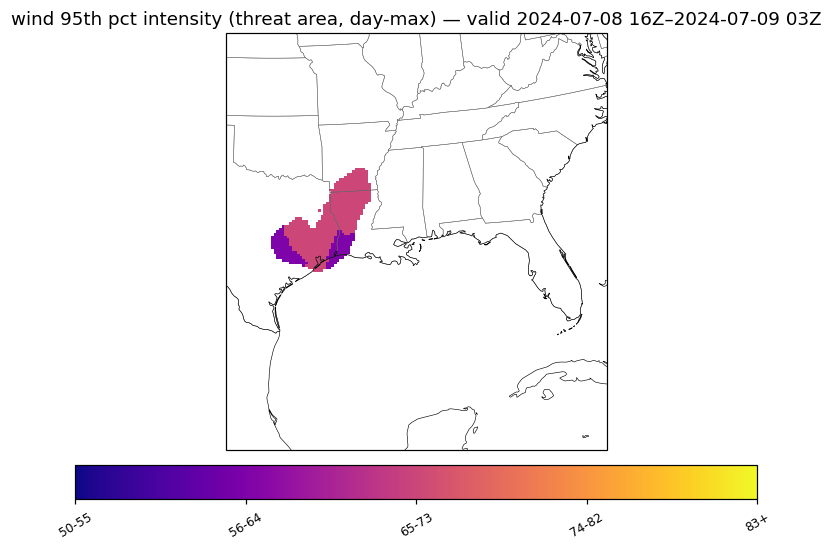

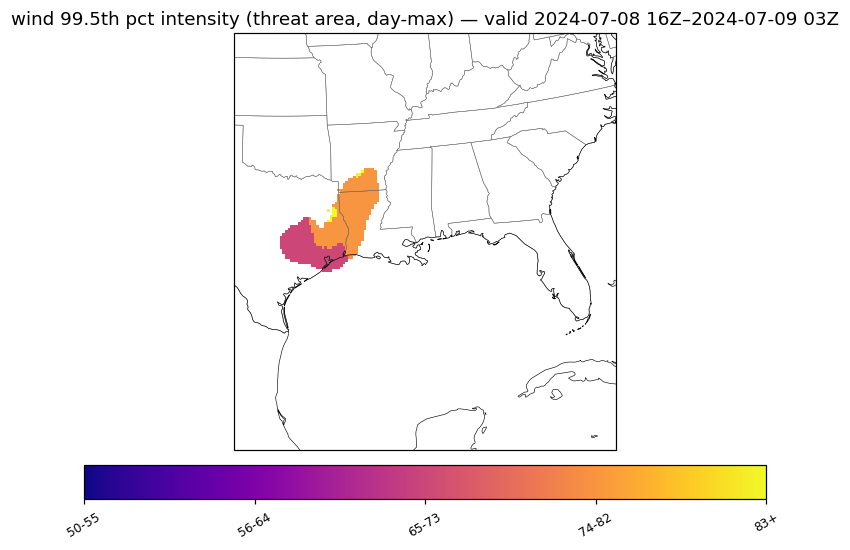

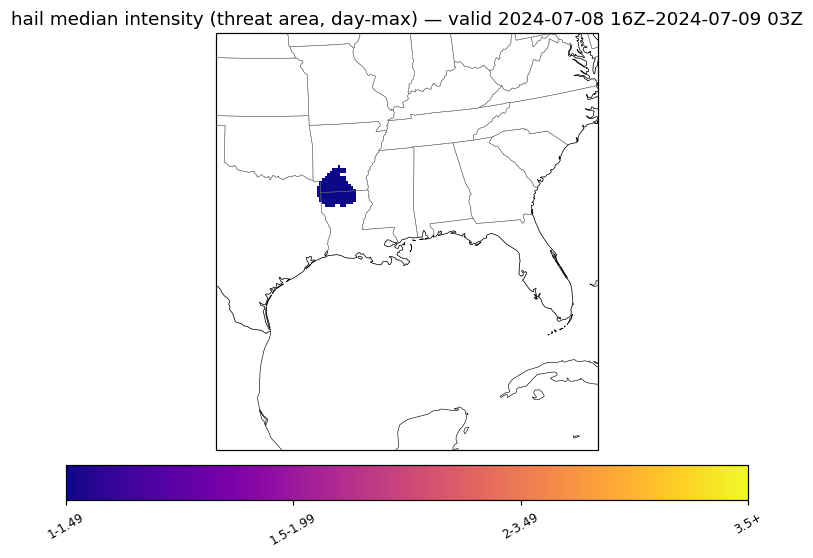

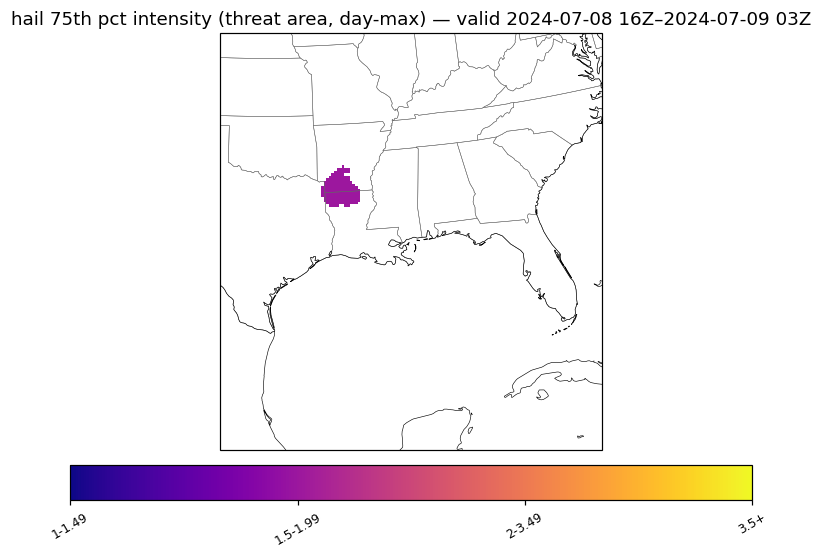

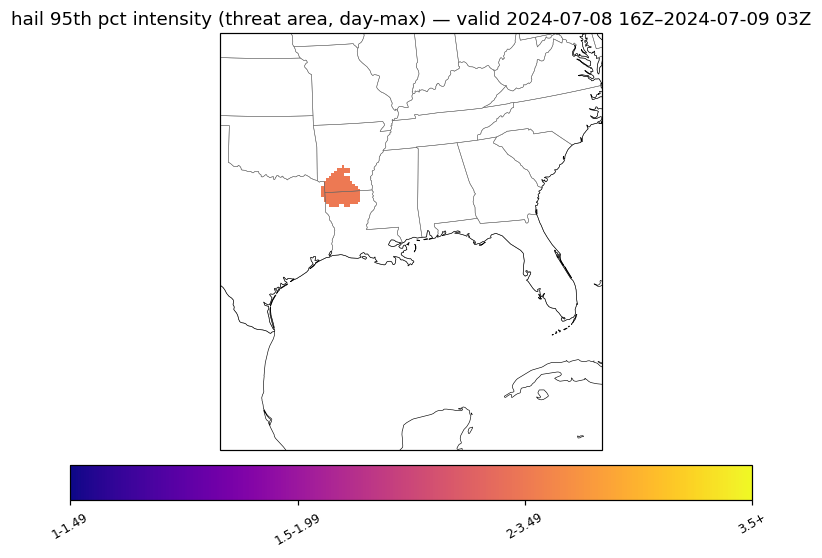

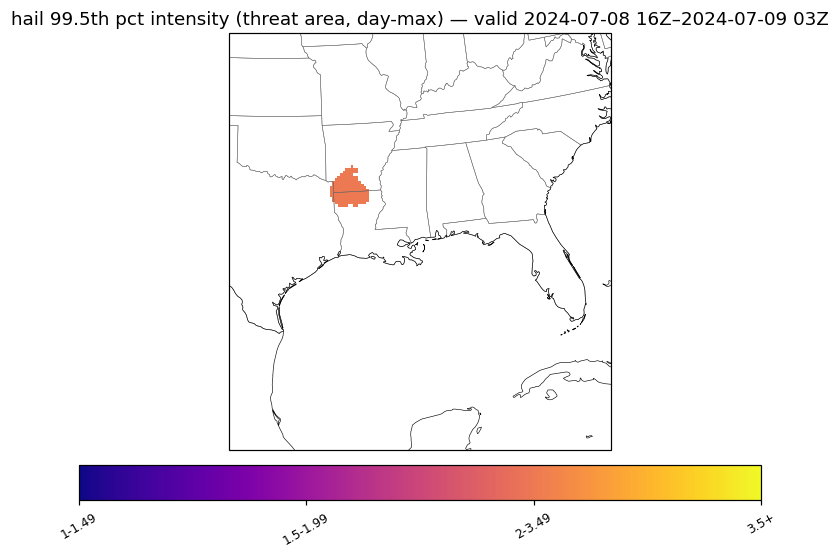

In [6]:
if preds:
    from IPython.display import Image, display
    v0 = RUN + timedelta(hours=min(FXX)); v1 = RUN + timedelta(hours=max(FXX))
    period = f'valid {v0:%Y-%m-%d %HZ}–{v1:%Y-%m-%d %HZ}'
    # cumulative daily CATEGORICAL across ALL hazards (SPC-style Day-1 categorical)
    combined = summary.combined_categorical(preds)
    plots.plot_categorical(combined['category'], 'all', f'cumulative daily categorical (all hazards) — {period}', '/tmp/_day.png')
    display(Image('/tmp/_day.png'))
    # day-MAX conditional-intensity bin for EACH hazard at the median (q=0.5),
    # 75th (q=0.75) and 90th (q=0.90) percentile: per-hour percentile bin, then the
    # element-wise max over hours (strongest intensity reached anywhere that day).
    # -1 = no mass; masked to the threat area below.
    for h in C.HAZARDS:
        daymax_h = summary.day_max({f: preds[f][f'p_{h}'] for f in FXX})
        for q, qlab in [(0.5, 'median'), (0.75, '75th pct'), (0.95, '95th pct'), (0.995, '99.5th pct')]:
            qb = np.stack([summary.percentile_intensity_bin(np.nan_to_num(preds[f][f'dist_{h}']), q) for f in FXX], axis=0).max(axis=0)
            qb = np.where(daymax_h >= C.SPC_PROB_LEVELS[h][0], qb, -1)  # threat area only
            plots.plot_intensity(qb, h, f'{h} {qlab} intensity (threat area, day-max) — {period}', f'/tmp/_int_{h}_{q}.png')
            display(Image(f'/tmp/_int_{h}_{q}.png'))

## Forecast vs observed reports — overlay on the day-max probability

59 tor reports in valid window 2024-07-08 16Z -> 2024-07-09 03Z


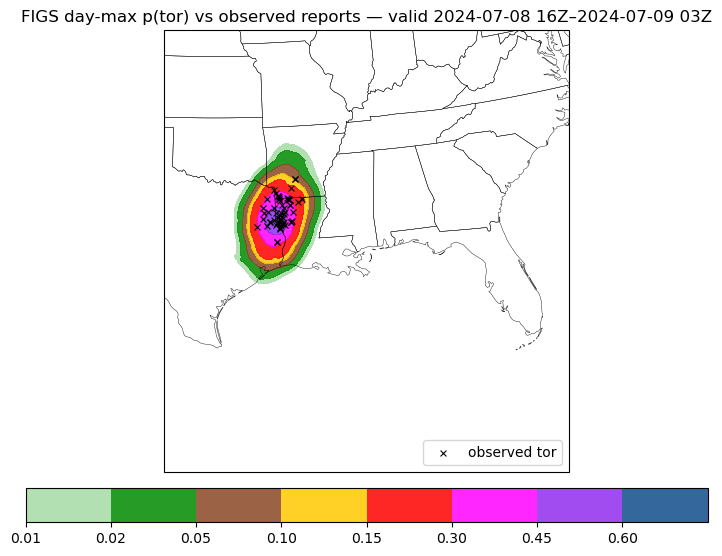

In [7]:
import cartopy.crs as ccrs, cartopy.feature as cfeature
from figs.data.grid import figs_xy, lcc_forward, figs_latlon
day = RUN.replace(hour=0)  # convective-day label / SPC archive date
# Observed reports over the FORECAST VALID WINDOW (RUN+min..max FXX). An evening
# event spills past 00Z into the next UTC day, so fetch every UTC day it spans
# and filter to the window — a 00Z-00Z calendar fetch would miss those reports.
v0 = RUN + timedelta(hours=min(FXX)); v1 = RUN + timedelta(hours=max(FXX))
udays = sorted({v0.replace(hour=0,minute=0,second=0,microsecond=0),
                v1.replace(hour=0,minute=0,second=0,microsecond=0)})
rep_all = pd.concat([reports.reports_for_day(d) for d in udays], ignore_index=True)
rep_all = rep_all[(rep_all.time >= v0) & (rep_all.time <= v1)]
rep = rep_all[rep_all.hazard == HAZARD].copy()
print(len(rep), HAZARD, 'reports in valid window', f'{v0:%Y-%m-%d %HZ}', '->', f'{v1:%Y-%m-%d %HZ}')
lat, lon = figs_latlon()
daymax = summary.day_max({f: preds[f][f'p_{HAZARD}'] for f in FXX}) if preds else None
levels = list(C.SPC_PROB_LEVELS[HAZARD]) + [1.0]
fig = plt.figure(figsize=(11,7)); ax = plt.axes(projection=ccrs.LambertConformal(central_longitude=-97.5, central_latitude=38.5))
ax.add_feature(cfeature.STATES, lw=0.3)
if MAP_EXTENT: ax.set_extent(MAP_EXTENT)
if daymax is not None:
    cf = ax.contourf(lon, lat, daymax, levels=levels, colors=plots.PROB_COLORS[HAZARD],
                     transform=ccrs.PlateCarree(), alpha=0.85, extend='neither')
    plt.colorbar(cf, ax=ax, orientation='horizontal', pad=0.03, shrink=0.8, ticks=C.SPC_PROB_LEVELS[HAZARD])
ax.scatter(rep.lon, rep.lat, s=18, c='black', marker='x', lw=0.8, transform=ccrs.PlateCarree(), label=f'observed {HAZARD}')
ax.set_title(f'FIGS day-max p({HAZARD}) vs observed reports — valid {v0:%Y-%m-%d %HZ}–{v1:%Y-%m-%d %HZ}'); ax.legend(loc='lower right'); plt.show()

### Capture: what fraction of observed reports fell inside each probability contour?

In [8]:
if preds is not None and len(rep):
    xc, yc = figs_xy(); x, y = lcc_forward(rep.lon.values, rep.lat.values)
    ix = np.round((x-xc[0])/(xc[1]-xc[0])).astype(int); iy = np.round((y-yc[0])/(yc[1]-yc[0])).astype(int)
    ok = (ix>=0)&(ix<len(xc))&(iy>=0)&(iy<len(yc))
    pvals = daymax[iy[ok], ix[ok]]
    print(f'{ok.sum()} in-domain reports | median forecast prob at report sites = {np.median(pvals):.3f}')
    for thr in C.SPC_PROB_LEVELS[HAZARD]:
        print(f'  captured at >= {int(thr*100):>2d}%: {100*(pvals>=thr).mean():5.1f}% of reports')
    # crude reliability for the day: report frequency vs forecast prob bin
    from figs.model.calibrate import reliability
    # (skipped here; see 02_training_progress for full reliability)

59 in-domain reports | median forecast prob at report sites = 0.409
  captured at >=  1%: 100.0% of reports
  captured at >=  2%: 100.0% of reports
  captured at >=  5%: 100.0% of reports
  captured at >= 10%:  96.6% of reports
  captured at >= 15%:  96.6% of reports
  captured at >= 30%:  89.8% of reports
  captured at >= 45%:  40.7% of reports
  captured at >= 60%:   0.0% of reports


### Observed vs predicted conditional intensity

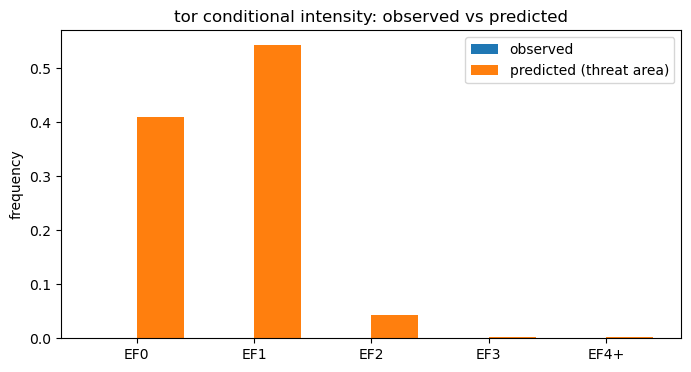

In [9]:
if preds is not None and len(rep):
    from figs.data.labels import intensity_bin
    labels = C.INTENSITY_BINS[HAZARD]['labels']; nb = len(labels)
    # observed intensity histogram (EF for tor; exclude EFU=-1)
    vals = rep.ef.values if HAZARD=='tor' else rep.magnitude.values
    obs = np.zeros(nb)
    for v in vals:
        b = intensity_bin(HAZARD, v)
        if b>=0: obs[b]+=1
    obs = obs/obs.sum() if obs.sum() else obs
    # predicted mean conditional distribution over the threat area (p>=5%)
    dist_day = np.nanmean([np.nan_to_num(preds[f][f'dist_{HAZARD}']) for f in FXX], axis=0)  # (nb,ny,nx)
    mask = daymax >= 0.05
    pred = dist_day[:, mask].mean(axis=1) if mask.any() else np.full(nb, np.nan)
    pred = pred/pred.sum()
    xpos = np.arange(nb); w=0.4
    fig, ax = plt.subplots(figsize=(8,4))
    ax.bar(xpos-w/2, obs, w, label='observed'); ax.bar(xpos+w/2, pred, w, label='predicted (threat area)')
    ax.set_xticks(xpos); ax.set_xticklabels(labels); ax.set_ylabel('frequency'); ax.legend()
    ax.set_title(f'{HAZARD} conditional intensity: observed vs predicted'); plt.show()

## 6-panel: FIGS prob+CIG vs SPC outlooks (tornado / wind / hail)

Top row = FIGS day-max probability (SPC colors) with significant (CIG≥2) hatching;
bottom row = the **actual SPC Day-1 probabilistic outlook contours**, pulled as
vectors from the IEM GIS archive and drawn on the same projection (significant-
severe area hatched). The issuance closest to RUN is used.

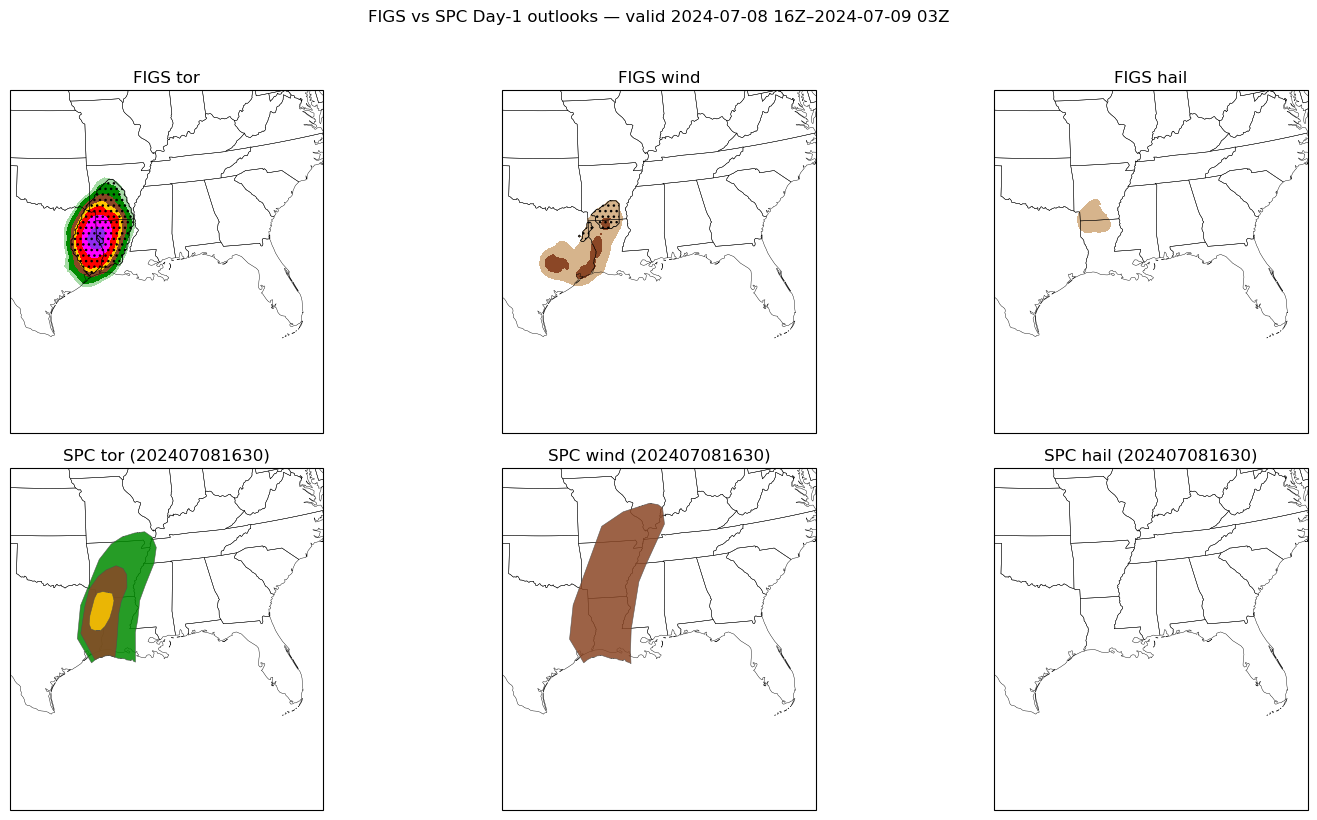

In [10]:
import cartopy.crs as ccrs, cartopy.feature as cfeature
from figs.products import cig as cigmod, spc
lat, lon = figs_latlon()
# actual SPC outlook contours from IEM (vector), selected to the run's issuance
spc_gdf = None
try:
    spc_gdf = spc.select_issuance(spc.fetch_spc_outlooks(RUN, day=1), RUN)
except Exception as e:
    print('SPC outlook fetch failed:', e)
spc_iss = (sorted(spc_gdf['ISSUE'].unique())[0] if spc_gdf is not None and len(spc_gdf) else 'n/a')
proj = ccrs.LambertConformal(central_longitude=-97.5, central_latitude=38.5)
fig = plt.figure(figsize=(16,8))
for j, h in enumerate(['tor','wind','hail']):
    ax = fig.add_subplot(2, 3, j+1, projection=proj)
    ax.add_feature(cfeature.STATES, lw=0.3)
    if MAP_EXTENT: ax.set_extent(MAP_EXTENT)
    if preds:
        dmax = summary.day_max({f: preds[f][f'p_{h}'] for f in FXX})
        lv = list(C.SPC_PROB_LEVELS[h]) + [1.0]
        ax.contourf(lon, lat, dmax, levels=lv, colors=plots.PROB_COLORS[h], transform=ccrs.PlateCarree(), extend='neither')
        # CIG derived HOUR-BY-HOUR (per-hour conditional dist), then maxed over
        # hours — matches summary.cumulative_categorical. Averaging the dist first
        # would dilute the upper tail and understate peak severity.
        cigmax = np.stack([cigmod.derive_cig_category(h, np.nan_to_num(preds[f][f'dist_{h}'])) for f in FXX], axis=0).max(axis=0)
        cigcat = np.where(dmax >= C.SPC_PROB_LEVELS[h][0], cigmax, 0)
        plots.overlay_cig(ax, lon, lat, cigcat)  # CIG1 dots / CIG2 diag / CIG3 cross, masked to prob area
    ax.set_title(f'FIGS {h}')
    ax2 = fig.add_subplot(2, 3, j+4, projection=proj)
    ax2.add_feature(cfeature.STATES, lw=0.3)
    if MAP_EXTENT: ax2.set_extent(MAP_EXTENT)
    spc.plot_spc_outlook(ax2, spc_gdf, h, plots.PROB_COLORS[h])  # filled by prob threshold + SIGN hatch
    ax2.set_title(f'SPC {h} ({spc_iss})')
_v0 = RUN + timedelta(hours=min(FXX)); _v1 = RUN + timedelta(hours=max(FXX))
fig.suptitle(f'FIGS vs SPC Day-1 outlooks — valid {_v0:%Y-%m-%d %HZ}–{_v1:%Y-%m-%d %HZ}', y=1.02); plt.tight_layout(); plt.show()

## Inspect a saved prediction netCDF

In [11]:
# import xarray as xr
# ds = xr.open_dataset(f'../Data/products/figs_{RUN:%Y%m%d_%HZ}.nc'); ds